## Assignment_Week4

**Instructions:**

- Please submit your work as either a .ipynb notebook file or a PDF file on Blackboard.

- Please make sure your name is included either in the file name or clearly written in your assignment.

- <span style="color:blue">**For all narrative sections of this assignment, such as the data description paragraph, please use Markdown formatting in the Jupyter notebook code cells. Do not write narratives as commented out text in Python cells.**</span> **Alternatively, you may choose to write the narrative portions in a separate Word document and submit both the Word doc and Python code files together.** Please refer to the final project folder on Blackboard for specific examples.

- If applicable, ensure that you label headings, subheadings, and other sections appropriately using Markdown's header formatting for clarity and organization.

- Please make sure all code is executed and displays the corresponding output.



**This assignment consists of two main parts**:

1. Implement a decision tree classifier using the Iris dataset.

2. Start our ANA540 course project, which includes the following three components:
   a) Research purpose/questions
   b) Dataset Description
   c) EDA (Exploratory Data Analysis)

So far, we have learned about regression models and classification models. You also now understand what kind of data is needed for machine learning. So now it's time to apply the knowledge we've acquired to a practical project, solidifying and reinforcing our understanding. This course project will be an excellent opportunity to put your learning into practice and deepen your comprehension of the concepts covered.

<br>

## Part 1: Decision Tree Classification with the Iris Dataset

#### Objective: Implement a decision tree classifier using the Iris dataset.
*Although pruning and confusion matrix were demonstrated in the week 4 instructional Jupyter notebook, for this classification tree task, pruning the tree and generating the confusion matrix are not required*


**Data Description**:

The Iris dataset consists of 150 samples. Each sample has four features: sepal length, sepal width, petal length, and petal width. The target variable is the species of the flower, which can be one of three possible classes: Setosa, Versicolour, and Virginica.

0: Setosa   
1: Versicolour     
2: Virginica

**Tasks:**

- 1. Load the Iris dataset.

- 2. Split the data into a training set and a testing set.

- 3. Train a decision tree classifier on the training data.

- 4. Evaluate the model's performance on the test set and report the accuracy. 

- 5. Visualize the classification tree.

- 6. Interpret your classification tree plot.

- 7. Predict the class for new incoming samples.

In [36]:
# Import libraries
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a dataframe from the data
df= pd.DataFrame(iris.data, columns = iris.feature_names)

# Add the target variable to the dataframe
df['target'] = iris.target

#Display the first few rows of the DataFrame to check
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


<br>

### Q1. Check some basic data information and statistics 
(5 pts)

1. Check number of rows and columns

2. Check data types of columns

3. Check summary statistics 

4. Check the distribution of the Target variable

5. Check for missing values

In [37]:
df.shape

(150, 5)

In [38]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

In [39]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


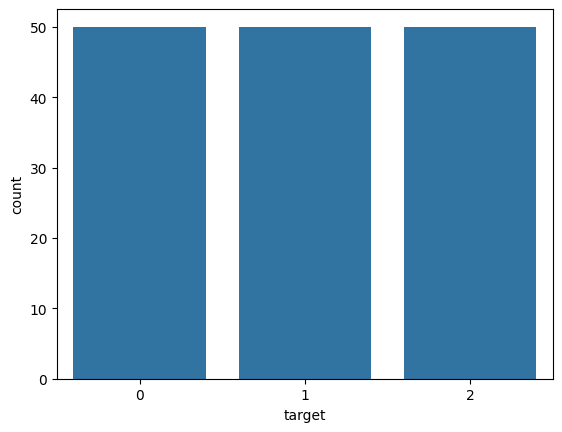

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="target")
plt.show()


In [41]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

### Q2: Data Splitting and Preparation
(5 pts)

Split the Iris dataset into training and test sets and inspect the size of both sets.

-  Allocate 70% of the data for training and 30% for testing.
-  Use random_state = 0
-  Display the size of the training and testing data

In [42]:
from sklearn.model_selection import train_test_split

y = df['target']
X = df.drop('target', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [43]:
print("X_train")
print(X_train.shape)

print("y_train")
print(y_train.shape)

print("X_test")
print(X_test.shape)

print("y_test")
print(y_test.shape)



X_train
(105, 4)
y_train
(105,)
X_test
(45, 4)
y_test
(45,)


### Q3: Decision Tree Model Training
(15 pts)

Train a decision tree classifier using the training data and then evaluate its performance on the test set.
- 1. Initialize the decision tree classifier
- 2. Train the classifier using the training data
- 3. Make predictions on the test set
- 4. Calculate and display the accuracy

<br>

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score  

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



Accuracy: 0.9777777777777777


### Q4: Visualize the Decision Tree
(10 pts)

Visualize the trained decision tree model to understand its classification decisions.

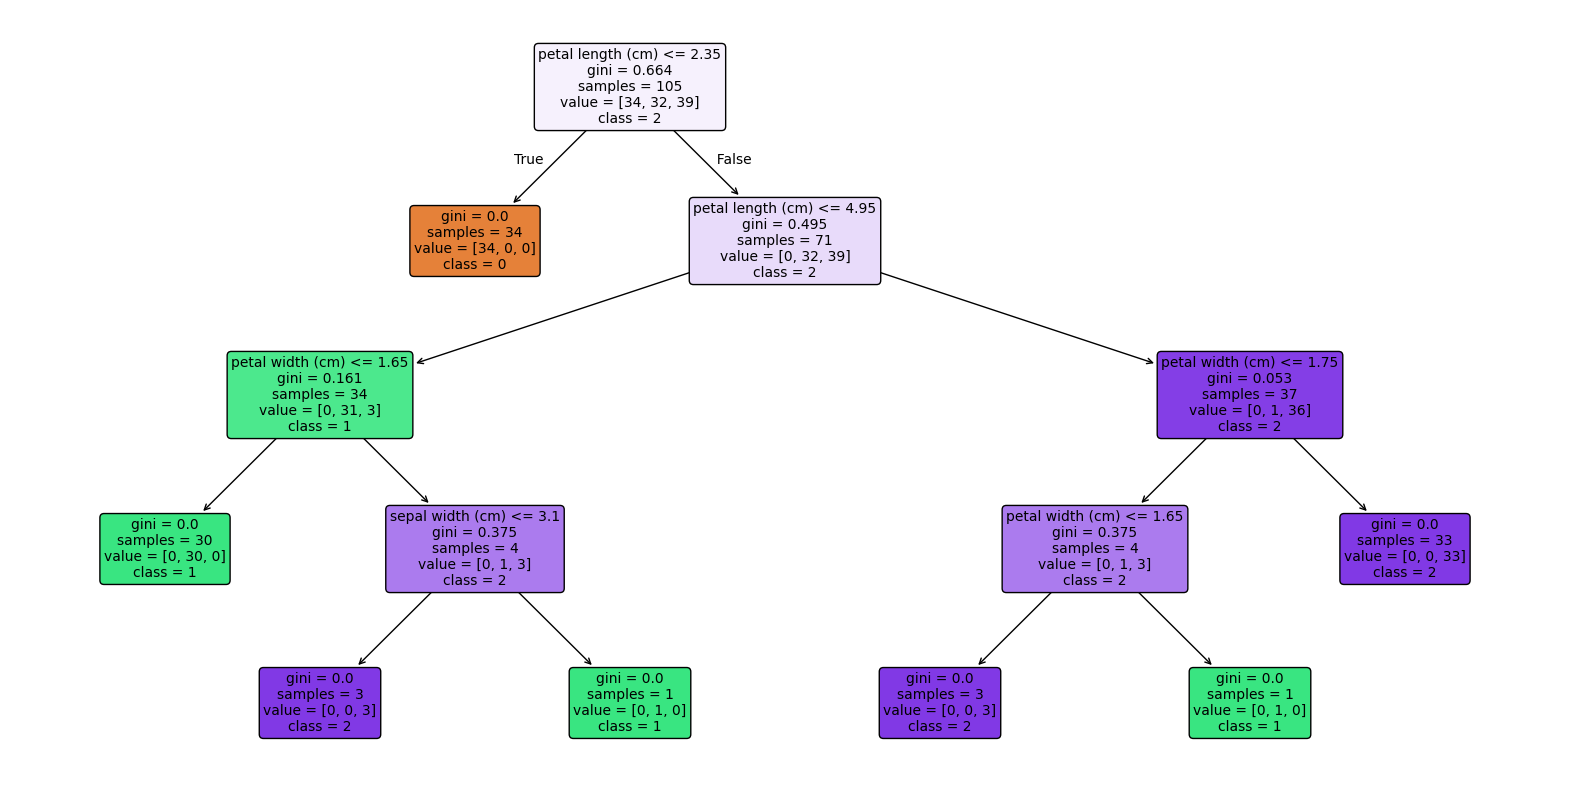

In [45]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))  
plot_tree(clf, 
        filled=True,
        rounded=True,
        feature_names=X.columns.tolist(),
        class_names=['0', '1', '2'],
        fontsize=10)
plt.show()

### Q5: Interpret the Decision Tree Plot
(15 pts)

Briefly interpret this classification tree. You can describe aspects such as:

- Which feature is used for the root node split?
- What is the depth of the tree?
- How many leaf nodes are there total?
- Which feature appears most often in the decision splits throughout the tree?
- How does the tree indicate true or false branches based on the direction of the lines/arrows?

*Besides the points above, you are also free to discuss any other observations or insights you find relevant to understanding the tree's decision-making process.*



Answer 
 1. Petal width
 2. 4
 3. 7
 4. Petal width and Petal length (both showed up two times)
 5. left branches represent the True condition, and right branches represent the False condition 

 * Additional: Petal width is strong indicator of the class 0


### Q6: Predict Class for New Samples
(10 pts)

Now, we have three new samples. We can use the generated classification tree (plot) to make predictions based on these measurements to see which iris species they belong to.
    
**New iris flower 1**:
- Sepal Length: 4.3    
- Sepal Width: 2.9     
- Petal Length: 1.9    
- Petal Width: 0.7



**New iris flower 2**:
- Sepal Length: 5.3
- Sepal Width: 2.9
- Petal Length: 5.0
- Petal Width: 1.8



**New iris flower 3**:
- Sepal Length: 5.1
- Sepal Width: 3.8
- Petal Length: 4.2
- Petal Width: 1.7

In [46]:
pred_df = pd.DataFrame({
    'sepal length (cm)': [4.3, 5.3, 5.1],
    'sepal width (cm)': [2.9, 2.9, 3.8], 
    'petal length (cm)':[1.9, 5.0, 4.2],
    'petal width (cm)': [0.7, 1.8, 1.7]
})

In [47]:
new_pred = clf.predict(pred_df)
pred_df['Prediction'] = new_pred


print(pred_df)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                4.3               2.9                1.9               0.7   
1                5.3               2.9                5.0               1.8   
2                5.1               3.8                4.2               1.7   

   Prediction  
0           0  
1           2  
2           1  


<br>

## Follow up

I was not sure what kind of plot do you want us to write here. Simply I added predicted results next to new features.

### Part 2: Starting Your ANA540 Machine Learning Project

#### Task 1: State Your Research Purpose and Questions

<span style="color:GREEN">**Please use 1-2 paragraphs to clearly state your research purpose or define the key questions you aim to address through your analysis.**</span>

Your research purpose explains the core goal or objective of your project. Why are you conducting this study and analysis?


Here are the key considerations for your machine learning project:

#### Define the Problem Statement:

- What specific issue or question do you want to address with machine learning?
- Is there a particular domain or industry you're interested in, such as healthcare, education, or social media?



#### Determine the Type of Machine Learning Problem:

- **Classification**: Will you predict categories or labels? (e.g. spam vs not spam)
- **Regression**: Will you forecast continuous numerical values? (e.g. housing prices)
- **Clustering**: Will you group data based on similarities, without prior labels? (optional learning materials covered Week 6)
- **Dimensionality Reduction**: Will you reduce the number of features while retaining information? (e.g. PCA) (Covered Week 6)

## Problem statement

The number of international tourists visiting Japan has dramatically increased thus making the country a worldwide destination for travelers. The substantial economic expansion has created a serious deficit of available lodging particularly in locations with high tourist interests and urban centers. Airbnb and similar platforms have provided essential substitute accommodations by enabling users to book rooms in various sized facilities spread throughout Japan.

The increasing demand promotes new investment possibilities and innovative solutions 　in the short-term rental business. The proposed analysis focuses on Airbnb booking trends within Japan's specific area to identify marketplace requirements for customer demand and generate mission-critical business intelligence. The research aims to support strategic choices through data analytics and machine learning methods for shortened rental market investors and owners alongside hospitality entrepreneurs looking to excel in this business environment.
As part of my CPT, I’m exploring new business opportunities in the hospitality and property management space. This project aims to analyze Airbnb booking occupancy in a specific area in Japan, providing actionable insights that could support investment or operational decisions.


### Machine learning problem

Regression problem: Given short-term rent data, predict the occupancy rate of a property

<br>

### Task 2: Dataset Description

- Remember, the quality and quantity of data can significantly influence the project's outcomes.
  
- Ensure you understand the features present in the dataset and what they represent.


- *Public Datasets: There are numerous publicly available datasets from platforms such as the UCI Machine Learning Repository, Kaggle, Google Dataset Search, US Open Data Portal, and Harvard Dataverse.*

- *Personal or Company Data: If you have access to proprietary data (either collected personally or from a company) that can be publicly disclosed, you may choose to use this. Ensure that the data doesn't violate any privacy guidelines or contain sensitive information.*

#### Write a Description:
<span style="color:GREEN">**For the dataset you choose, please write a concise 1-2 paragraph to describe the dataset,**</span> such as why you chose this dataset and how it relates to your research topic. **Also write down the attributes for each feature (or features you will use) in the dataset**. 

The description should cover:

- **Source**: Where the dataset originates from, including any relevant links or references.
- **Relevance**: Explain the significance of this dataset in relation to your research topic and why it was chosen.
- **Feature Attributes**: Provide a brief overview of the features within the dataset, highlighting the ones you intend to use. For each feature, mention its data type (e.g., numerical, categorical), its meaning, and any unique characteristics.


In addition to the three essential points mentioned above, you may choose to include the following aspects in your dataset description：

- **Contextual Information**: Offer any additional details that might help understand the dataset's context, such as the time period it covers, geographic limitations, or the population it represents.
- **Critical Evaluation**: Reflect on any potential biases, limitations, or challenges within the dataset that could impact your analysis or the generalizability of your findings.

*As we learn more, it will also be possible to replace the dataset later on.*

### Dataset Description

The dataset used for this project includes Airbnb listings in a specific region in Japan, using web scraping. The dataset has 1287 records with 41 columns, including occupancy rate, price per night and other property information. Some columns include missing values, we need to fill these missing values 0 or delete it based on employed models. 
 Regarding target variable occupancy_rate’s basic statistics, mean is 0.44 and median is 0.40. If population skewness drifts +-0.5, distribution is “moderately skewed,” and it’s +-1, it’s “strongly skewed.” This target variable’s population skewness is 0.18; it is well inside the “roughly symmetric”.

|	Column Name	|	Description	|
|	---	|	---	|
|	room_id	|	Unique identifier for the Airbnb listing.	|
|	descriptionOriginalLanguage	|	Language in which the original listing description was written.	|
|	propertyType	|	Type of property (e.g., apartment, house, cabin).	|
|	roomType	|	Type of room offered (e.g., entire place, private room, shared room).	|
|	personCapacity	|	Maximum number of guests the listing can accommodate.	|
|	location	|	General location or neighborhood of the listing.	|
|	title	|	Title or headline of the listing.	|
|	description	|	Full textual description of the listing provided by the host.	|
|	highlights	|	Key selling points or features emphasized in the listing.	|
|	cancellationPolicies	|	Details about the host’s cancellation policy (e.g., flexible, strict).	|
|	amenities	|	List of amenities offered (e.g., Wi-Fi, kitchen, parking).	|
|	occupancy_rate	|	Estimated occupancy rate (e.g., proportion of booked days over a period).	|
|	rating.accuracy	|	Guest rating of how accurately the listing matches its description.	|
|	rating.checking	|	Guest rating of the check-in process.	|
|	rating.cleanliness	|	Guest rating of the cleanliness of the listing.	|
|	rating.communication	|	Guest rating of the host’s communication.	|
|	rating.location	|	Guest rating of the listing’s location.	|
|	rating.value	|	Guest rating of value for the price paid.	|
|	rating.guestSatisfaction	|	Overall satisfaction score from guests.	|
|	rating.reviewsCount	|	Total number of guest reviews for the listing.	|
|	host.isSuperHost	|	Indicates whether the host has Superhost status.	|
|	host.isVerified	|	Indicates whether the host has verified their identity.	|
|	host.ratingCount	|	Number of reviews the host has received.	|
|	host.ratingAverage	|	Average rating of the host across listings.	|
|	host.hostDetails	|	Additional structured information about the host (e.g., profile info).	|
|	host.timeAsHost.months	|	Number of months the user has been hosting.	|
|	host.timeAsHost.years	|	Number of years the user has been hosting.	|
|	subDescription.items	|	Short bullet-style highlights or features pulled from the listing.	|
|	price.price	|	Current listed price per night.	|
|	price.originalPrice	|	Original (possibly non-discounted) nightly price.	|
|	price.discountedPrice	|	Discounted price per night, if applicable.	|
|	brandHighlights.title	|	Title of promotional/marketing highlight (e.g., “Top-rated host”).	|
|	brandHighlights.subtitle	|	Subtitle elaborating the brand highlight.	|
|	brandHighlights.hasGoldenLaurel	|	Boolean flag for special Airbnb recognition (e.g., golden laurel badge).	|
|	houseRules.general	|	General house rules (e.g., no smoking, no pets).	|
|	price.breakDown.serviceFee.price	|	Airbnb’s service fee added to the booking.	|
|	price.breakDown.serviceFee.description	|	Description of the service fee.	|
|	price.breakDown.specialOffer.price	|	Price related to a special promotional offer.	|
|	price.breakDown.specialOffer.description	|	Description of the special offer.	|
|	price.breakDown.cleaningFee.price	|	Cleaning fee charged per stay.	|
|	price.breakDown.cleaningFee.description	|	Description of the cleaning fee.	|
|	price.breakDown.earlyBirdDiscount.price	|	Discount amount for early bookings.	|
|	price.breakDown.earlyBirdDiscount.description	|	Description of the early bird discount.	|
|	distance_km	|	Distance (in kilometers) from a target location (e.g., city center).	|
|	target_area_flag	|	Flag indicating if the listing is within a defined target area (e.g., tourist district).	|

<br>

### Task 3: Exploratory Data Analysis (EDA)
Perform exploratory data analysis on the dataset you have selected. The primary goals of EDA are to gain a deeper understanding of the dataset's characteristics and to identify any issues related to data quality, such as missing values or outliers, that may require attention. EDA is an iterative process that can reveal insights to inform the next steps of your analysis or model building.

Specifically, based on your own dataset, you can explore your dataset from these aspects (*you may choose to address all of the following points or focus on a selection of them that are most relevant to your study's needs*):

- **Sample Size and Basic Information**: Present the overall sample size and review basic dataset information.
- **Descriptive Statistics**: Examine basic statistics for each feature, including count, mean, standard deviation, etc., to get a sense of the data's distribution.
- **Missing Values and Outliers**: Check for missing values and identify any outliers that may need to be addressed.
- **Visualization**: Create various visualizations (e.g., histograms, scatter plots, box plots) to uncover relationships between features and the target variable. Visual analysis can help in identifying patterns, trends, or anomalies.
- **Feature Correlation**: Analyze the correlation between features to understand how they relate to each other and to the target variable. This can highlight potential multicollinearity or identify promising predictors for your model.

<span style="color:GREEN">**After completing your EDA, write 1-2 paragraph documenting the key findings. This should include any significant patterns or relationships uncovered, data quality issues identified, and how these insights could potentially shape your subsequent analysis steps or model selection.**</span>

In [48]:
prj_df = pd.read_csv("/Users/nkohei/Workspace/plaize/airbnb/ocp_analysis/df_final.csv")

In [49]:
prj_df.shape

(1287, 41)

In [50]:
print(prj_df.describe())


            room_id  occupancy_rate  rating.accuracy  rating.checking  \
count  1.287000e+03     1287.000000      1105.000000      1105.000000   
mean   6.803435e+17        0.440482         4.726452         4.743412   
std    5.363512e+17        0.327712         0.364341         0.362335   
min    1.192480e+06        0.000000         1.000000         1.000000   
25%    4.437400e+07        0.133333         4.670000         4.680000   
50%    8.916192e+17        0.400000         4.820000         4.850000   
75%    1.177563e+18        0.733333         4.930000         4.940000   
max    1.376783e+18        1.000000         5.000000         5.000000   

       rating.cleanliness  rating.communication  rating.location  \
count         1105.000000           1105.000000      1105.000000   
mean             4.729864              4.768688         4.613502   
std              0.336775              0.367031         0.378745   
min              1.000000              1.000000         1.000000   
25

In [51]:
prj_df.isnull().sum()

room_id                                         0
occupancy_rate                                  0
propertyType_major_Entire home                  0
propertyType_major_Entire rental unit           0
propertyType_major_Entire villa                 0
propertyType_major_Other                        0
propertyType_major_Private room in home         0
propertyType_major_Private room in ryokan       0
propertyType_major_Room in hotel                0
cancellationPolicies_Flexible                   0
cancellationPolicies_Moderate                   0
cancellationPolicies_Non-refundable             0
cancellationPolicies_Refundable                 0
cancellationPolicies_Strict                     0
rating.accuracy                               182
rating.checking                               182
rating.cleanliness                            182
rating.communication                          182
rating.location                               182
rating.value                                  182


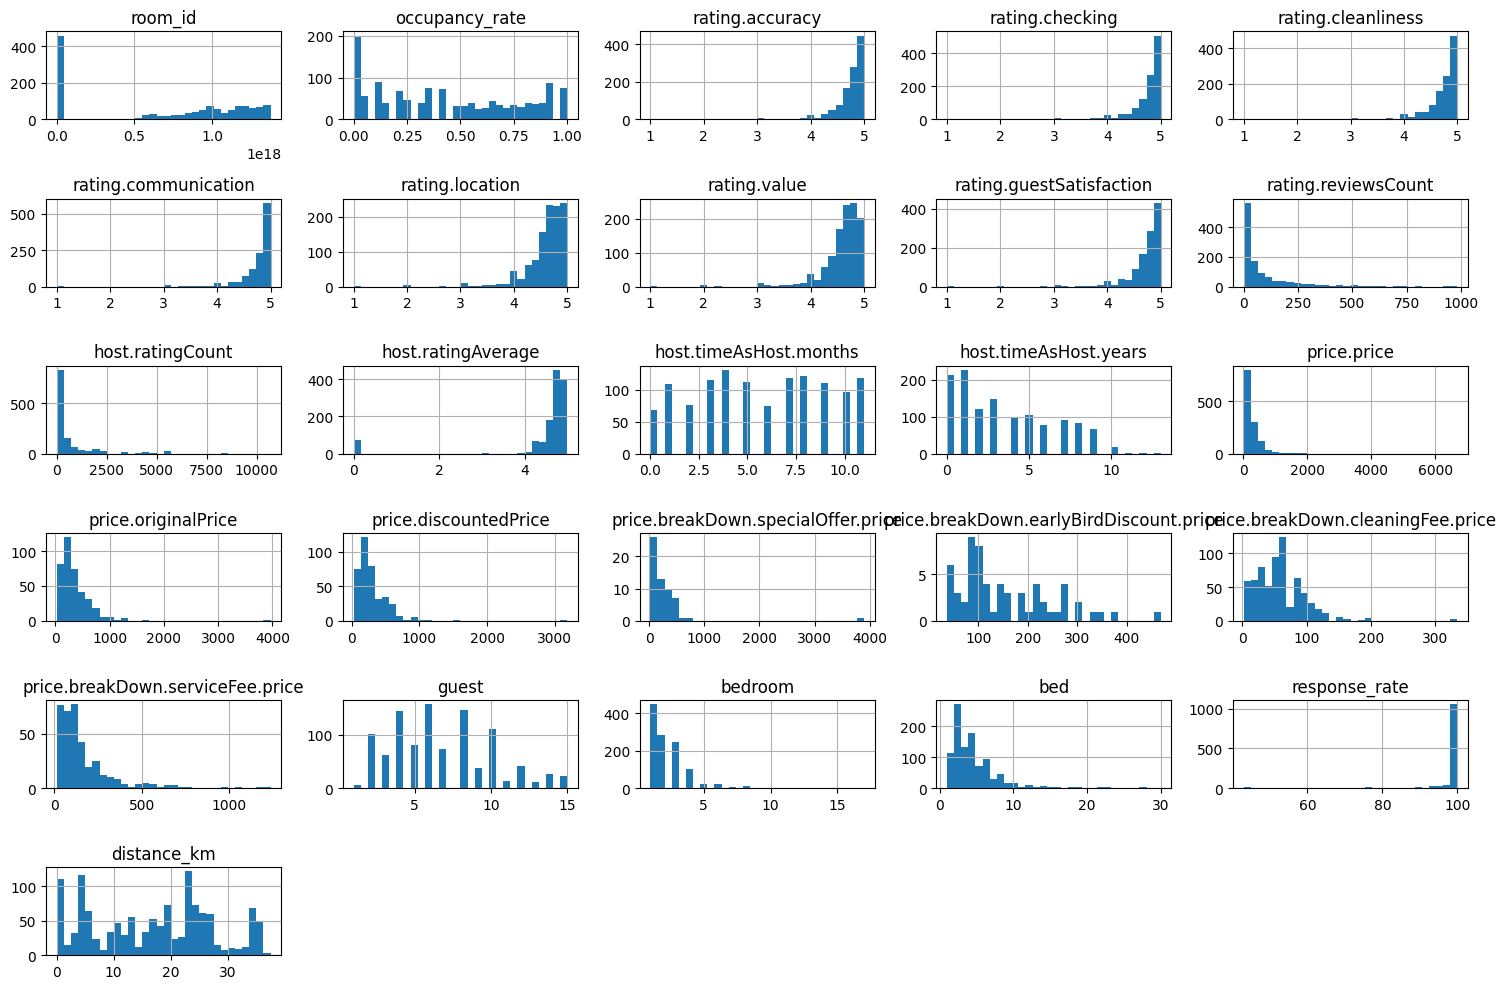

In [52]:
import matplotlib.pyplot as plt

num_cols = prj_df.select_dtypes(include=['number']).columns

prj_df[num_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

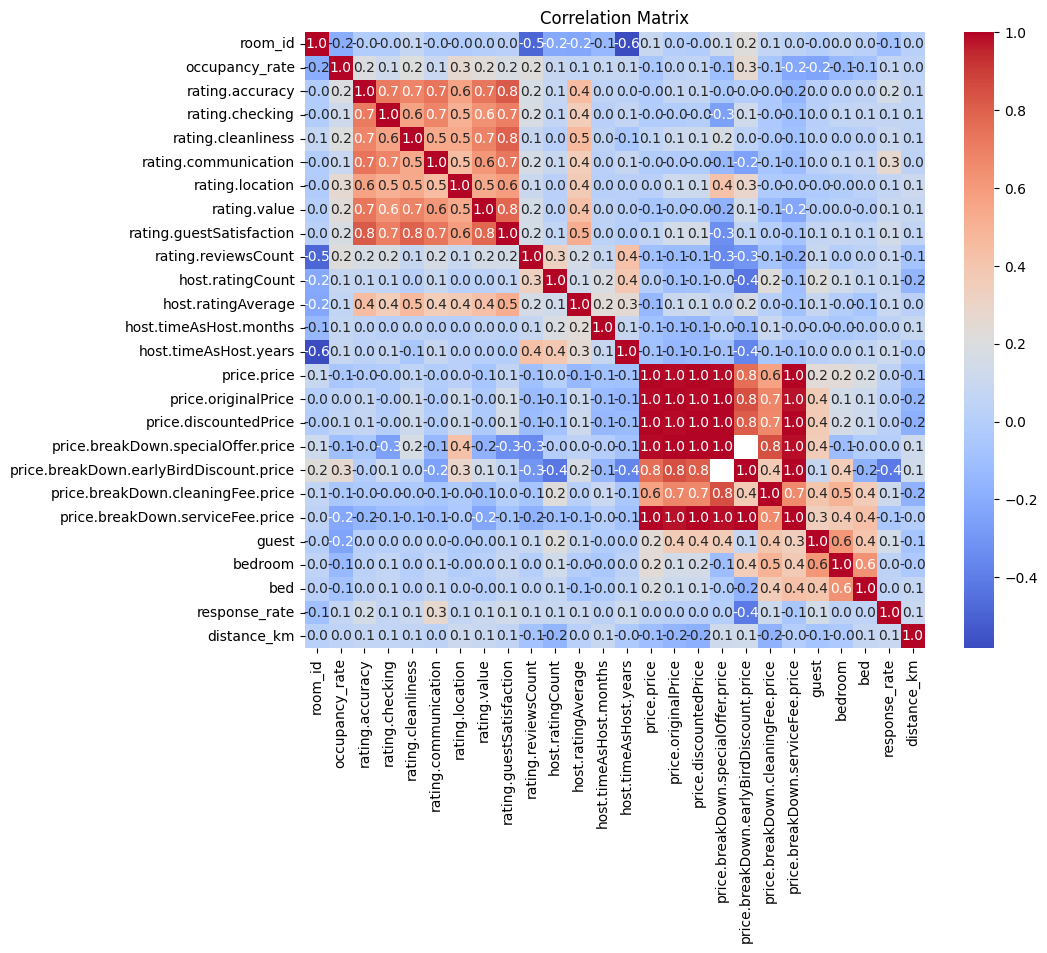

In [53]:
corr_matrix = prj_df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".1f")
plt.title("Correlation Matrix")
plt.show()

Mean Squared Error: 0.094
R^2 Score: 0.083


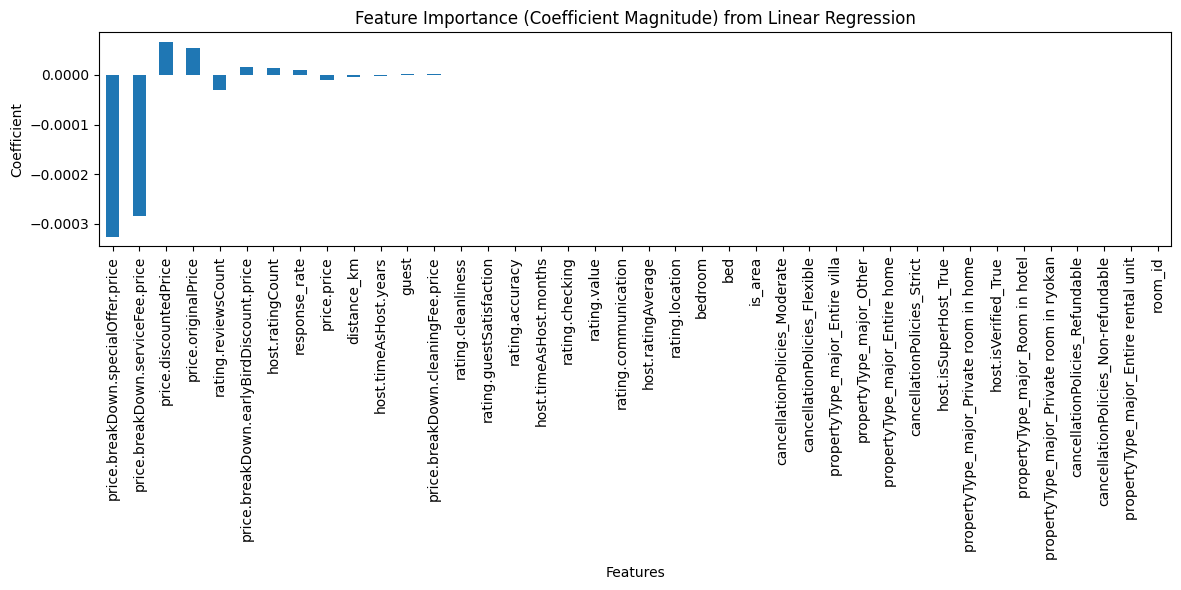

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df_filled = prj_df.fillna(0)
df_numeric = pd.get_dummies(df_filled, drop_first=True)


X = df_numeric.drop(columns=['occupancy_rate'])
y = df_numeric['occupancy_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


y_pred = lr_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error: {:.3f}".format(mse))
print("R^2 Score: {:.3f}".format(r2))


coefficients = lr_model.coef_
feature_importance = pd.Series(coefficients, index=X_train.columns)

# Sort the feature importance by absolute value
feature_importance = feature_importance.reindex(feature_importance.abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 6))
feature_importance.plot(kind='bar')
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Feature Importance (Coefficient Magnitude) from Linear Regression")
plt.tight_layout()
plt.show()

### Findings

The target variable, Occupancy rate has right skewness, but it is not severe. also we can say it's lightly uniform distribution. 
Also rating system creates some unique distribution.Because of the rating system expects user to put 5 star as a baseline, a lot of rating related features are skewed toward 5. Given many different features, we may need to normalize a lot of features to run models. 
Also we see some quick insights and potential preprocessing for occupancy rate prediction from initial simple linear regression model. Higher contribution features are mostly missing value, so we may need to cleaning up those features. 
